# 01 · Paradigms Hands-On: Supervised, Unsupervised, Semi-Supervised, RL and Drift

Companion notebook for `01-Introduction-to-ML-Paradigms.md` (Sections 13–19). Every number quoted in the note's new worked examples is recomputed here.

1. **Part A:** the same dataset (two moons) under three paradigms: supervised, unsupervised (K-means, spectral clustering) and semi-supervised (`LabelPropagation`)
2. **Part B:** ERM on the class "Division" table: the learned threshold
3. **Part C:** RL arithmetic: discounted return, Bellman policy evaluation, a 3-armed bandit
4. **Part D:** tabular Q-learning on a 4×4 gridworld (numpy only), checked against value iteration
5. **Part E:** drift detection: PSI and the two-sample KS test (scipy), covariate drift vs concept drift
6. **Part F:** small checks: InfoNCE loss, label-propagation on a chain, No-Free-Lunch counting, labelling cost

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.semi_supervised import LabelPropagation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, adjusted_rand_score
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

## Part A — One dataset, three paradigms

Two interleaving half-moons (300 points). The **true** labels exist, but each paradigm is allowed to see a different amount of them:

| Paradigm | Labels it may use |
|---|---|
| Supervised (all labels) | all 240 training labels |
| Supervised (few labels) | only 6 labels (3 per class) |
| Unsupervised | none |
| Semi-supervised | the same 6 labels + the 234 unlabelled training points |

Accuracy is always measured on the same 60-point held-out test set.

In [2]:
X, y = make_moons(n_samples=300, noise=0.1, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

rng = np.random.default_rng(0)
few = np.concatenate([rng.choice(np.where(y_tr == c)[0], 3, replace=False) for c in (0, 1)])
print("train:", len(X_tr), "test:", len(X_te), "| labelled indices used by 'few':", few)

results = {}
# 1. Supervised, all labels
sup_all = SVC(kernel="rbf", gamma=2.0).fit(X_tr, y_tr)
results["supervised, 240 labels"] = accuracy_score(y_te, sup_all.predict(X_te))
# 2. Supervised, 6 labels only
sup_few = SVC(kernel="rbf", gamma=2.0).fit(X_tr[few], y_tr[few])
results["supervised, 6 labels"] = accuracy_score(y_te, sup_few.predict(X_te))
# 3. Semi-supervised: -1 marks 'unlabelled'
y_semi = np.full_like(y_tr, -1)
y_semi[few] = y_tr[few]
lp = LabelPropagation(kernel="knn", n_neighbors=10, max_iter=2000).fit(X_tr, y_semi)
results["semi-supervised, 6 labels + 234 unlabelled"] = accuracy_score(y_te, lp.predict(X_te))
for k, v in results.items():
    print(f"{k:45s} test accuracy = {v:.3f}")

train: 240 test: 60 | labelled indices used by 'few': [146 126 199   5  16  11]
supervised, 240 labels                        test accuracy = 1.000
supervised, 6 labels                          test accuracy = 0.750
semi-supervised, 6 labels + 234 unlabelled    test accuracy = 1.000


In [3]:
# Unsupervised: no labels at all. Clusters have arbitrary IDs, so compare with ARI
# (adjusted Rand index: 1 = identical partition, ~0 = random) and best-permutation accuracy.
def best_perm_acc(y_true, c):
    return max(accuracy_score(y_true, c), accuracy_score(y_true, 1 - c))

km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X)
sc = SpectralClustering(n_clusters=2, affinity="nearest_neighbors", n_neighbors=15, random_state=0).fit(X)
for name, lab in [("K-means", km.labels_), ("Spectral clustering", sc.labels_)]:
    print(f"{name:20s} ARI = {adjusted_rand_score(y, lab):.3f}  best-permutation accuracy = {best_perm_acc(y, lab):.3f}")

K-means              ARI = 0.234  best-permutation accuracy = 0.743
Spectral clustering  ARI = 0.960  best-permutation accuracy = 0.990


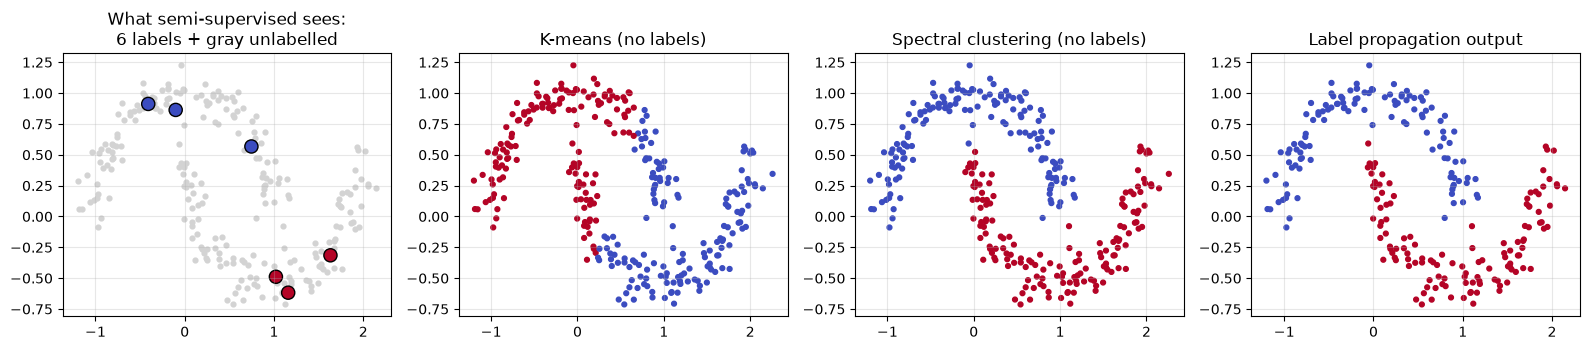

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
ax[0].scatter(X_tr[:, 0], X_tr[:, 1], c="lightgray", s=12)
ax[0].scatter(X_tr[few, 0], X_tr[few, 1], c=y_tr[few], cmap="coolwarm", s=90, edgecolor="k")
ax[0].set_title("What semi-supervised sees:\n6 labels + gray unlabelled")
ax[1].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="coolwarm", s=12); ax[1].set_title("K-means (no labels)")
ax[2].scatter(X[:, 0], X[:, 1], c=sc.labels_, cmap="coolwarm", s=12); ax[2].set_title("Spectral clustering (no labels)")
ax[3].scatter(X_tr[:, 0], X_tr[:, 1], c=lp.transduction_, cmap="coolwarm", s=12); ax[3].set_title("Label propagation output")
plt.tight_layout(); plt.show()

**Reading the result.** K-means minimises within-cluster squared distance, so it cuts the moons with a straight boundary: its inductive bias (convex, round clusters) is wrong for this data. Spectral clustering uses a nearest-neighbour graph, so its bias (clusters = connected regions) matches. It is sensitive to the graph: with `n_neighbors=10` instead of 15 the graph falls apart into small pieces and the ARI drops to about 0.40. Label propagation uses the same graph idea **plus** 6 labels to name the clusters, which is the cluster assumption of semi-supervised learning in action.

## Part B — ERM on the Division table

Learn a threshold `t` for "first division vs not" from the 5 slide rows by minimising the empirical 0-1 risk.

In [5]:
T = np.array([67, 81, 53, 42, 69]); D = np.array([1, 1, 2, 3, 1])
first = (D == 1).astype(int)
cands = np.arange(40, 85)
risk = np.array([np.mean((T >= t).astype(int) != first) for t in cands])
zero = cands[risk == 0]
print("thresholds with zero training error: from", zero.min(), "to", zero.max())
print("max-margin choice (midpoint of 53 and 67):", (53 + 67) / 2, "| true rule: 60")
print("second-division boundary midpoint (42, 53):", (42 + 53) / 2, "| true rule: 45")
for t in [45, 53, 55, 60, 67, 68, 70]:
    print(t, np.mean((T >= t).astype(int) != first))

thresholds with zero training error: from 54 to 67
max-margin choice (midpoint of 53 and 67): 60.0 | true rule: 60
second-division boundary midpoint (42, 53): 47.5 | true rule: 45
45 0.2
53 0.2
55 0.0
60 0.0
67 0.0
68 0.2
70 0.4


## Part C — RL arithmetic

### C1. Discounted return

In [6]:
def discounted_return(rewards, gamma):
    G = 0.0
    for r in reversed(rewards):          # G_t = r_{t+1} + gamma * G_{t+1}
        G = r + gamma * G
    return G

r = [-1, -1, -1, 10]
for g in [0.0, 0.5, 0.9, 1.0]:
    print(f"gamma={g}: G0 = {discounted_return(r, g):.4f}")
print("suffix returns (gamma=0.9):", [round(discounted_return(r[k:], 0.9), 4) for k in range(4)])
print("constant reward 1 forever: 1/(1-gamma) =", 1 / (1 - 0.9), "for 0.9 and", round(1 / (1 - 0.99), 4), "for 0.99")

gamma=0.0: G0 = -1.0000
gamma=0.5: G0 = -0.5000
gamma=0.9: G0 = 4.5800
gamma=1.0: G0 = 7.0000
suffix returns (gamma=0.9): [4.58, 6.2, 8.0, 10.0]
constant reward 1 forever: 1/(1-gamma) = 10.000000000000002 for 0.9 and 100.0 for 0.99


### C2. Policy evaluation by the Bellman equation: V = R + γPV  ⇒  V = (I − γP)⁻¹R

In [7]:
P = np.array([[0.8, 0.2], [0.4, 0.6]]); R = np.array([2.0, -1.0]); g = 0.9
print("exact V:", np.linalg.solve(np.eye(2) - g * P, R))
v = np.zeros(2)
for k in range(1, 201):
    v = R + g * P @ v
    if k in (1, 2, 3, 50, 200):
        print(f"iteration {k:3d}: {v}")

exact V: [11.5625  6.875 ]
iteration   1: [ 2. -1.]
iteration   2: [ 3.26 -0.82]
iteration   3: [ 4.1996 -0.2692]
iteration  50: [11.511   6.8235]
iteration 200: [11.5625  6.875 ]


In [8]:
# Corridor S0 - S1 - S2 - G, reward -1 per move, gamma 0.9. 'left' from S0 bumps the wall and stays.
g = 0.9
print("optimal policy (always right): V* =", [-sum(g**k for k in range(n)) for n in (3, 2, 1)])
A = np.array([[1 - g*0.5, -g*0.5, 0], [-g*0.5, 1, -g*0.5], [0, -g*0.5, 1]])
print("uniform random policy:        V  =", np.linalg.solve(A, -np.ones(3)))

optimal policy (always right): V* = [-2.71, -1.9, -1.0]
uniform random policy:        V  = [-6.1408 -5.2832 -3.3774]


### C3. A 3-armed Bernoulli bandit and ε-greedy

In [9]:
mu = np.array([0.2, 0.5, 0.7]); eps = 0.1
print("uniform random arm:", mu.mean())
print("eps-greedy once the greedy arm is the best arm:", (1 - eps) * mu.max() + eps * mu.mean())

# simulate: sample-average estimates, eps-greedy, 2000 runs x 1000 pulls
rng = np.random.default_rng(1)
runs, steps = 2000, 1000
avg = np.zeros(steps); best = np.zeros(steps)
for _ in range(runs):
    Q = np.zeros(3); N = np.zeros(3)
    for t in range(steps):
        a = rng.integers(3) if rng.random() < eps else int(np.argmax(Q))
        rew = float(rng.random() < mu[a])
        N[a] += 1; Q[a] += (rew - Q[a]) / N[a]
        avg[t] += rew; best[t] += (a == 2)
avg /= runs; best /= runs
print("mean reward over the last 100 pulls:", avg[-100:].mean().round(4), "| share of best arm:", best[-100:].mean().round(4))

uniform random arm: 0.4666666666666666
eps-greedy once the greedy arm is the best arm: 0.6766666666666666


mean reward over the last 100 pulls: 0.677 | share of best arm: 0.9306


## Part D — Q-learning on a 4×4 gridworld

States 0…15 (row-major), start 0, goal 15 (terminal), a pit at 5 (terminal, reward −10). Every move costs −1; reaching the goal gives +10. Actions: up, right, down, left; moving into a wall leaves the agent in place.

Q-learning update: Q(s,a) ← Q(s,a) + α [ r + γ maxₐ' Q(s',a') − Q(s,a) ].

In [10]:
N_S, N_A, GOAL, PIT, gamma = 16, 4, 15, 5, 0.9
MOVES = [(-1, 0), (0, 1), (1, 0), (0, -1)]   # up, right, down, left
ARROWS = "^>v<"

def step(s, a):
    r, c = divmod(s, 4)
    dr, dc = MOVES[a]
    nr, nc = min(max(r + dr, 0), 3), min(max(c + dc, 0), 3)
    s2 = nr * 4 + nc
    if s2 == GOAL: return s2, 10.0, True
    if s2 == PIT:  return s2, -10.0, True
    return s2, -1.0, False

# Ground truth by value iteration (model-based: uses step() as the known model P, R)
V = np.zeros(N_S)
for it in range(1000):
    V_new = V.copy()
    for s in range(N_S):
        if s in (GOAL, PIT): continue
        V_new[s] = max(r + gamma * (0 if done else V[s2]) for s2, r, done in (step(s, a) for a in range(N_A)))
    if np.max(np.abs(V_new - V)) < 1e-10:
        V = V_new; break
    V = V_new
print("value iteration converged after", it, "sweeps")
print(V.reshape(4, 4).round(3))

value iteration converged after 6 sweeps
[[ 1.81   3.122  4.58   6.2  ]
 [ 3.122  0.     6.2    8.   ]
 [ 4.58   6.2    8.    10.   ]
 [ 6.2    8.    10.     0.   ]]


In [11]:
# Model-free Q-learning: the agent only sees (s, a, r, s') samples
rng = np.random.default_rng(42)
Q = np.zeros((N_S, N_A)); alpha, eps = 0.1, 0.1
ep_returns = []
starts = [s for s in range(N_S) if s not in (GOAL, PIT)]
for ep in range(20000):
    # exploring starts: every 4th episode begins at state 0 (the real start), the rest at a random state,
    # so that rarely visited states (e.g. 4, next to the pit) also get enough updates
    s = 0 if ep % 4 == 0 else int(rng.choice(starts))
    done, G, t = False, 0.0, 0
    while not done and t < 100:
        a = rng.integers(N_A) if rng.random() < eps else int(np.argmax(Q[s]))
        s2, r, done = step(s, a)
        target = r + (0.0 if done else gamma * Q[s2].max())
        Q[s, a] += alpha * (target - Q[s, a])
        G += r; s = s2; t += 1
    ep_returns.append(G)
V_q = Q.max(axis=1); V_q[[GOAL, PIT]] = 0
print("max |V_Q - V*| over non-terminal states: %.2e" % np.abs(V_q - V).max())
grid = [("G" if s == GOAL else "X" if s == PIT else ARROWS[int(np.argmax(Q[s]))]) for s in range(N_S)]
print("greedy policy learned by Q-learning:")
print("\n".join(" ".join(grid[r*4:(r+1)*4]) for r in range(4)))
from_start = np.array(ep_returns[::4])   # episodes that began at state 0
print("mean undiscounted return from state 0, first 100 such episodes:", from_start[:100].mean().round(2),
      "| last 100:", from_start[-100:].mean().round(2))

max |V_Q - V*| over non-terminal states: 1.42e-14
greedy policy learned by Q-learning:
> > > v
v X > v
> v > v
> > > G
mean undiscounted return from state 0, first 100 such episodes: 2.46 | last 100: 3.87


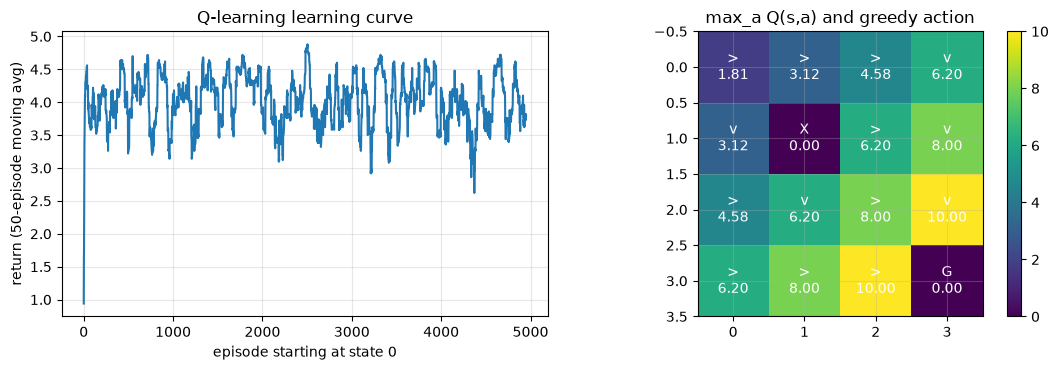

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(np.convolve(from_start, np.ones(50) / 50, mode="valid"))
ax[0].set_xlabel("episode starting at state 0"); ax[0].set_ylabel("return (50-episode moving avg)"); ax[0].set_title("Q-learning learning curve")
im = ax[1].imshow(V_q.reshape(4, 4), cmap="viridis")
for s in range(N_S):
    ax[1].text(s % 4, s // 4, f"{grid[s]}\n{V_q[s]:.2f}", ha="center", va="center", color="w")
ax[1].set_title("max_a Q(s,a) and greedy action"); plt.colorbar(im, ax=ax[1]); plt.tight_layout(); plt.show()

In [13]:
# One hand-checkable Q-update (Practice Problem in the note)
Q_sa, r, maxQ_next, alpha, g = 2.0, 1.0, 5.0, 0.1, 0.9
print("new Q =", Q_sa + alpha * (r + g * maxQ_next - Q_sa))

new Q = 2.35


## Part E — Drift detection: PSI and the KS test

PSI = Σᵢ (aᵢ − eᵢ) ln(aᵢ / eᵢ) over bins, where e = expected (training) share and a = actual (live) share.

In [14]:
def psi(expected, actual, eps=1e-4):
    e = np.clip(np.asarray(expected, float), eps, None); a = np.clip(np.asarray(actual, float), eps, None)
    e, a = e / e.sum(), a / a.sum()
    return float(np.sum((a - e) * np.log(a / e)))

e = np.array([0.10, 0.20, 0.40, 0.20, 0.10]); a = np.array([0.05, 0.15, 0.35, 0.25, 0.20])
print("per-bin terms:", (a - e) * np.log(a / e))
print("PSI (worked example) =", round(psi(e, a), 4))
print("PSI (tiny shift)     =", round(psi(e, [0.11, 0.19, 0.41, 0.19, 0.10]), 4))
print("PSI two bins (0.5,0.5)->(0.7,0.3) =", round(psi([.5, .5], [.7, .3]), 4))
print("PSI = KL(a||e) + KL(e||a):", round(np.sum(a*np.log(a/e)) + np.sum(e*np.log(e/a)), 4))
print("empty-bin case, eps=1e-4:", round(psi([.3, .4, .3], [.5, .5, 0]), 4))

per-bin terms: [0.0347 0.0144 0.0067 0.0112 0.0693]
PSI (worked example) = 0.1362
PSI (tiny shift)     = 0.0022
PSI two bins (0.5,0.5)->(0.7,0.3) = 0.1695
PSI = KL(a||e) + KL(e||a): 0.1362
empty-bin case, eps=1e-4: 2.5256


In [15]:
# KS: worked example from the note
x = np.array([1, 2, 3, 4, 5.]); y = np.array([3, 4, 5, 6, 7.])
print(stats.ks_2samp(x, y))

# Simulated monitoring: training feature ~ N(0,1); live data shifts gradually
rng = np.random.default_rng(7)
train = rng.normal(0, 1, 5000)
edges = np.quantile(train, np.linspace(0, 1, 11)); edges[0], edges[-1] = -np.inf, np.inf   # 10 equal-frequency bins
e_share = np.histogram(train, edges)[0] / len(train)
print(f"{'shift':>6} {'PSI':>8} {'KS D':>8} {'KS p':>10}")
for shift in [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]:
    live = rng.normal(shift, 1, 2000)
    a_share = np.histogram(live, edges)[0] / len(live)
    ks = stats.ks_2samp(train, live)
    print(f"{shift:6.2f} {psi(e_share, a_share):8.4f} {ks.statistic:8.4f} {ks.pvalue:10.2e}")

KstestResult(statistic=np.float64(0.4000000000000001), pvalue=np.float64(0.873015873015873), statistic_location=np.float64(3.0), statistic_sign=np.int8(1))
 shift      PSI     KS D       KS p
  0.00   0.0043   0.0164   8.32e-01
  0.05   0.0053   0.0348   6.17e-02
  0.10   0.0323   0.0786   4.07e-08
  0.25   0.0678   0.1129   2.66e-16
  0.50   0.2777   0.2260   1.98e-64
  1.00   1.0442   0.4066  4.33e-212


In [16]:
# Covariate drift vs concept drift: what happens to a fixed model?
rng = np.random.default_rng(3)
def make(n, shift=0.0, flip=False):
    X = rng.normal(shift, 1, (n, 2))
    y = (X[:, 0] + X[:, 1] > 0).astype(int)
    if flip:                                   # concept drift: the rule itself changes
        y = (X[:, 0] - X[:, 1] > 0).astype(int)
    return X, y
Xa, ya = make(4000)
clf = LogisticRegression().fit(Xa, ya)
for name, (Xb, yb) in {"no drift": make(2000), "covariate drift (inputs shifted by +1.5)": make(2000, 1.5),
                       "concept drift (rule changed)": make(2000, flip=True)}.items():
    print(f"{name:42s} accuracy = {accuracy_score(yb, clf.predict(Xb)):.3f}  "
          f"KS on x1: D = {stats.ks_2samp(Xa[:, 0], Xb[:, 0]).statistic:.3f}")

no drift                                   accuracy = 0.999  KS on x1: D = 0.015


covariate drift (inputs shifted by +1.5)   accuracy = 1.000  KS on x1: D = 0.538
concept drift (rule changed)               accuracy = 0.512  KS on x1: D = 0.025


Covariate drift moved the inputs (KS sees it) but the boundary x₁ + x₂ = 0 is still right, so accuracy stays high. Concept drift left P(X) unchanged (KS sees nothing) yet accuracy collapses to about chance level. **Input monitoring alone cannot catch concept drift; you need delayed labels.**

## Part F — Small checks used in the note

In [17]:
# InfoNCE / contrastive loss with cosine similarities 0.9 (positive), 0.1 and 0.3 (negatives)
s = np.array([0.9, 0.1, 0.3])
for tau in (0.5, 0.1):
    z = np.exp(s / tau)
    print(f"tau={tau}: loss = {-np.log(z[0] / z.sum()):.4f}")
print("chance-level loss with 3 candidates: ln 3 =", round(np.log(3), 4))

# Harmonic label propagation on a 5-node chain, f1 = 1, f5 = 0
L = np.array([[2, -1, 0], [-1, 2, -1], [0, -1, 2.]])
print("f2, f3, f4 =", np.linalg.solve(L, [1, 0, 0]))

# K-means objective (SSE) for two candidate clusterings
pts = np.array([1, 2, 3, 10, 11, 12.])
sse = lambda parts: sum(((p - p.mean())**2).sum() for p in parts)
print("SSE {1,2,3}|{10,11,12} =", sse([pts[:3], pts[3:]]), "| SSE {1,2,3,10}|{11,12} =", sse([pts[:4], pts[4:]]))

# No-Free-Lunch counting: boolean functions on 2 inputs consistent with 3 labelled points
X4 = list(itertools.product([0, 1], repeat=2))
train = {X4[0]: 0, X4[1]: 1, X4[2]: 1}
cons = [f for f in itertools.product([0, 1], repeat=4) if all(f[X4.index(k)] == v for k, v in train.items())]
print("functions:", 2**4, "| consistent:", len(cons), cons, "| predictions on (1,1):", [f[3] for f in cons])

# Labelling cost: 100,000 tweets x 30 s x 3 annotators at INR 300/hour
hours = 100_000 * 30 * 3 / 3600
print("hours:", hours, "| cost INR:", hours * 300, "| 1,000 labels only:", 1000 * 30 * 3 / 3600 * 300)

tau=0.5: loss = 0.4075
tau=0.1: loss = 0.0028
chance-level loss with 3 candidates: ln 3 = 1.0986
f2, f3, f4 = [0.75 0.5  0.25]
SSE {1,2,3}|{10,11,12} = 4.0 | SSE {1,2,3,10}|{11,12} = 50.5
functions: 16 | consistent: 2 [(0, 1, 1, 0), (0, 1, 1, 1)] | predictions on (1,1): [0, 1]
hours: 2500.0 | cost INR: 750000.0 | 1,000 labels only: 7500.0
